In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [ ]:
def wavg(series, weights):
    valid = series.notna() & weights.notna()
    values = series[valid]
    w = weights[valid]
    return np.average(values, weights=w) if len(values) else np.nan
  
def build_datasets(csv_path, year_weights, guard_threshold=0.25):
    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

    g = df.groupby("Symbol", group_keys=False)

    # --- Daily features ---
    df["log_close"] = np.log(df["Close"])
    df["logret_1"] = g["log_close"].diff(1)
    df["logret_5"] = g["log_close"].diff(5)
    df["logret_21"] = g["log_close"].diff(21)

    df["logvol_5"] = (
        g["logret_1"].rolling(5).std().reset_index(level=0, drop=True)
    )
    df["logvol_21"] = (
        g["logret_1"].rolling(21).std().reset_index(level=0, drop=True)
    )

    df["log_volume"] = np.log(df["Volume"].clip(lower=1))
    df["logvolchg_1"] = g["log_volume"].diff(1)
    df["vol_ma_21"] = (
        g["Volume"].rolling(21).mean().reset_index(level=0, drop=True)
    )

    # Optional forward label if you still want it for another part
    df["logret_fwd_1"] = g["logret_1"].shift(-1)
    df["y"] = (df["logret_fwd_1"] > 0).astype(int)

    feature_cols = [
        "logret_1",
        "logret_5",
        "logret_21",
        "logvol_5",
        "logvol_21",
        "logvolchg_1",
        "vol_ma_21",
        "Weight",
        "Sector",
    ]

    df_model = df.dropna(subset=feature_cols).reset_index(drop=True)

    # --- Add year weights ---
    df_tmp = df_model.copy()
    df_tmp["Year"] = df_tmp["Date"].dt.year
    df_tmp["YearWeight"] = df_tmp["Year"].map(year_weights)
    df_tmp = df_tmp.dropna(subset=["YearWeight"]).copy()

    # Guardrail against extreme daily returns
    df_tmp = df_tmp[df_tmp["logret_1"].abs() <= guard_threshold].copy()

    # --- Yearly stock summary ---
    yearly = (
        df_tmp.groupby(["Symbol", "Sector", "Year"], as_index=False)
        .agg(
            mean_logret_1=("logret_1", "mean"),
            sd_logret_1=("logret_1", "std"),
            mean_logret_5=("logret_5", "mean"),
            mean_logret_21=("logret_21", "mean"),
            mean_logvol_21=("logvol_21", "mean"),
            mean_logvolchg_1=("logvolchg_1", "mean"),
            mean_vol_ma_21=("vol_ma_21", "mean"),
            Weight=("Weight", "first"),
            YearWeight=("YearWeight", "first"),
        )
    )

    # --- Weighted stock-level features ---
    weighted_stock = (
        yearly.groupby(["Symbol", "Sector"], as_index=False)
        .apply(
            lambda x: pd.Series(
                {
                    "W_mean_logret_1": wavg(x["mean_logret_1"], x["YearWeight"]),
                    "W_sd_logret_1": wavg(x["sd_logret_1"], x["YearWeight"]),
                    "W_mean_logret_5": wavg(x["mean_logret_5"], x["YearWeight"]),
                    "W_mean_logret_21": wavg(x["mean_logret_21"], x["YearWeight"]),
                    "W_mean_logvol_21": wavg(x["mean_logvol_21"], x["YearWeight"]),
                    "W_mean_logvolchg_1": wavg(x["mean_logvolchg_1"], x["YearWeight"]),
                    "W_mean_vol_ma_21": wavg(x["mean_vol_ma_21"], x["YearWeight"]),
                    "Weight": x["Weight"].iloc[0],
                }
            )
        )
        .reset_index(drop=True)
    )

    weighted_stock["W_annual_logret"] = weighted_stock["W_mean_logret_1"] * 252
    weighted_stock["W_annual_return"] = np.exp(weighted_stock["W_annual_logret"]) - 1
    weighted_stock["W_annual_logvol"] = weighted_stock["W_sd_logret_1"] * np.sqrt(252)

    return df, df_model, weighted_stock
  
CLUSTER_FEATURES = [
    "W_mean_logret_5",
    "W_mean_logret_21",
    "W_mean_logvol_21",
    "W_sd_logret_1",
    "W_mean_logvolchg_1",
    "Weight",
]

def detect_outliers_mahalanobis(weighted_stock, feature_cols, alpha=0.001):
    df_feat = weighted_stock[["Symbol", "Sector"] + feature_cols].dropna().copy()

    X = df_feat[feature_cols].values

    # Standardize before distance-based methods
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    mean_vec = X_scaled.mean(axis=0)
    cov_mat = np.cov(X_scaled, rowvar=False)

    # In case covariance is near-singular
    cov_inv = np.linalg.pinv(cov_mat)

    diff = X_scaled - mean_vec
    md = np.sqrt(np.sum(diff @ cov_inv * diff, axis=1))

    # Squared Mahalanobis distance follows chi-square approximately
    md_sq = md**2
    df_chi = X_scaled.shape[1]
    p_values = 1 - chi2.cdf(md_sq, df=df_chi)

    df_feat["Mahalanobis_D2"] = md_sq
    df_feat["p_value"] = p_values
    df_feat["Outlier"] = df_feat["p_value"] < alpha

    return df_feat, X_scaled, scaler
  
def get_clean_clustering_data(weighted_stock, feature_cols, alpha=0.001):
    outlier_df, _, _ = detect_outliers_mahalanobis(
        weighted_stock, feature_cols, alpha=alpha
    )

    clean_df = outlier_df.loc[~outlier_df["Outlier"]].copy()
    clean_X = clean_df[feature_cols].values

    clean_scaler = StandardScaler()
    clean_X_scaled = clean_scaler.fit_transform(clean_X)

    return outlier_df, clean_df, clean_X_scaled

In [5]:
def choose_k_kmeans(X_scaled, k_min=2, k_max=10, random_state=42):
    ks = list(range(k_min, k_max + 1))
    inertias = []
    silhouettes = []

    for k in ks:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    plt.figure(figsize=(8, 4))
    plt.plot(ks, inertias, marker="o")
    plt.xlabel("k")
    plt.ylabel("WCSS / Inertia")
    plt.title("K-means Elbow Method")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(ks, silhouettes, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title("K-means Silhouette Scores")
    plt.show()

    best_k = ks[int(np.argmax(silhouettes))]
    return {"k_values": ks, "inertia": inertias, "silhouette": silhouettes, "best_k": best_k}
  
  
def choose_k_hierarchical(X_scaled, k_min=2, k_max=10, method="ward"):
    Z = linkage(X_scaled, method=method)

    plt.figure(figsize=(12, 5))
    dendrogram(Z, no_labels=True)
    plt.title(f"Hierarchical Dendrogram ({method})")
    plt.xlabel("Stocks")
    plt.ylabel("Distance")
    plt.show()

    ks = list(range(k_min, k_max + 1))
    silhouettes = []

    for k in ks:
        hc = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = hc.fit_predict(X_scaled)
        silhouettes.append(silhouette_score(X_scaled, labels))

    plt.figure(figsize=(8, 4))
    plt.plot(ks, silhouettes, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title(f"Hierarchical Silhouette Scores ({method})")
    plt.show()

    best_k = ks[int(np.argmax(silhouettes))]
    return {"k_values": ks, "silhouette": silhouettes, "best_k": best_k}

In [6]:
def run_kmeans(clean_df, X_scaled, k=3, random_state=42):
    model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = model.fit_predict(X_scaled)

    result = clean_df.copy()
    result["Cluster"] = labels
    return result, model
  
def run_hierarchical(clean_df, X_scaled, k=3, linkage_method="ward"):
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    labels = model.fit_predict(X_scaled)

    result = clean_df.copy()
    result["Cluster"] = labels
    return result, model
  
def profile_clusters(result_df, feature_cols):
    cluster_summary = (
        result_df.groupby("Cluster")[feature_cols]
        .mean()
        .round(4)
    )

    cluster_sizes = result_df["Cluster"].value_counts().sort_index()
    cluster_summary["n_stocks"] = cluster_sizes

    return cluster_summary

C:\Users\cynth\AppData\Local\Temp\ipykernel_8472\585080095.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Number of outliers: 19
    Symbol                  Sector  Mahalanobis_D2       p_value
386      Q  Information Technology      489.747822  0.000000e+00
422     SW               Materials      170.541117  0.000000e+00
410   SNDK  Information Technology      155.031878  0.000000e+00
341   NVDA  Information Technology      143.916155  0.000000e+00
124   CVNA  Consumer Discretionary      119.895190  0.000000e+00
1     AAPL  Information Technology      109.878441  0.000000e+00
451    TTD  Communication Services       79.152904  5.329071e-15
320   MSFT  Information Technology       65.420358  3.540168e-12
408   SMCI  Information Technology       61.646920  2.081779e-11
204    GEV             Industrials       39.126634  6.759921e-07
31    AMZN  Consumer Discretionary       38.550355  8.767006e-07
39     APP  Information Technology       30.896327  2.653108e-05
316   MRNA             Health Care       30.019069  3.898168e-05
104   COIN              Financials       28.603571  7.229672e-05
21

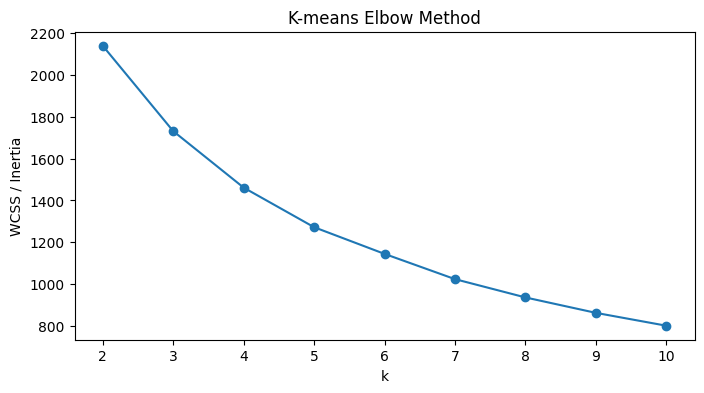

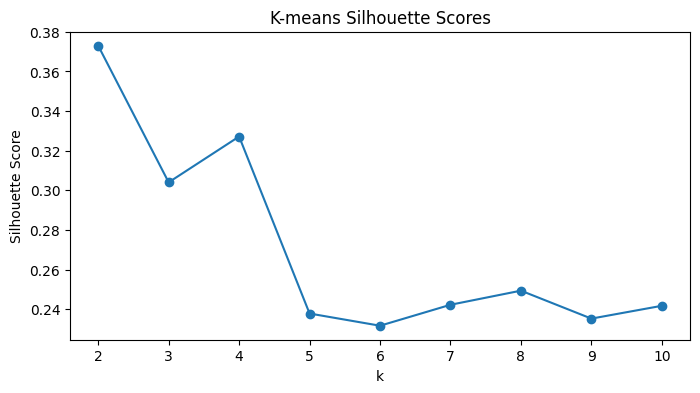

Best k for K-means: 2


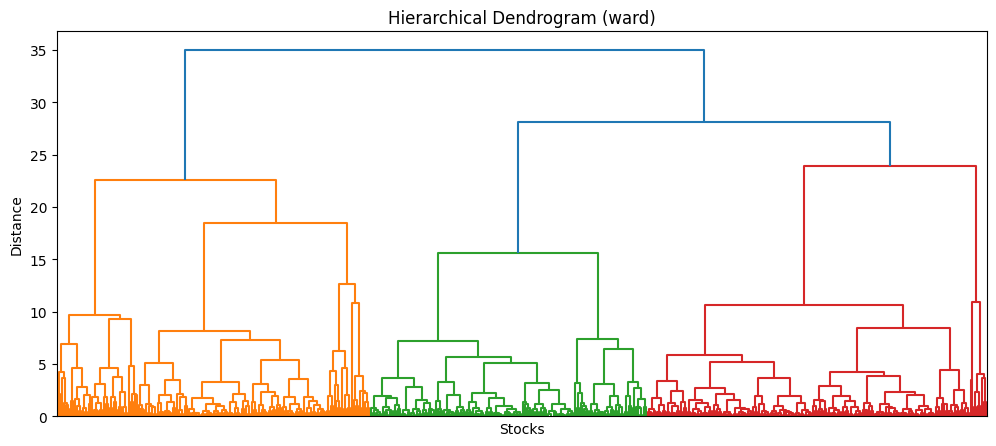

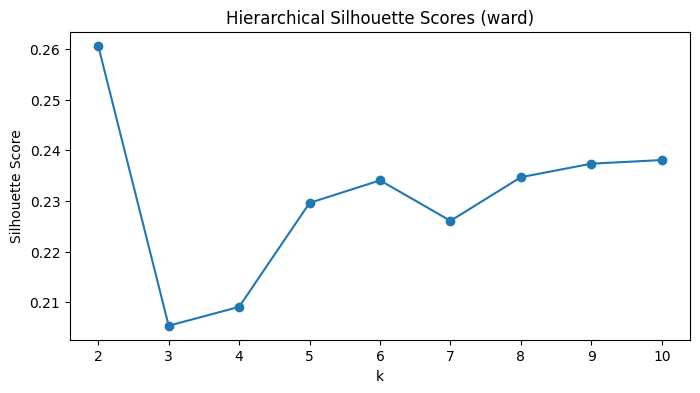

Best k for Hierarchical: 2


In [8]:
year_weights = {
    2020: 1,
    2021: 2,
    2022: 3,
    2023: 4,
    2024: 5,
    2025: 6,
}

df, df_model, weighted_stock = build_datasets(
    "data/sp500_5yr_with_sectors_weights.csv",
    year_weights=year_weights,
    guard_threshold=0.25
)

outlier_df, clean_df, clean_X_scaled = get_clean_clustering_data(
    weighted_stock,
    CLUSTER_FEATURES,
    alpha=0.001
)

print("Number of outliers:", outlier_df["Outlier"].sum())

print(
    outlier_df.loc[outlier_df["Outlier"], ["Symbol", "Sector", "Mahalanobis_D2", "p_value"]]
    .sort_values("Mahalanobis_D2", ascending=False)
    .head(20)
)

kmeans_k_results = choose_k_kmeans(clean_X_scaled, k_min=2, k_max=10)
print("Best k for K-means:", kmeans_k_results["best_k"])

hier_k_results = choose_k_hierarchical(clean_X_scaled, k_min=2, k_max=10, method="ward")
print("Best k for Hierarchical:", hier_k_results["best_k"])

In [9]:
best_k_kmeans = kmeans_k_results["best_k"]
best_k_hier = hier_k_results["best_k"]

kmeans_result, kmeans_model = run_kmeans(clean_df, clean_X_scaled, k=best_k_kmeans)
hier_result, hier_model = run_hierarchical(clean_df, clean_X_scaled, k=best_k_hier, linkage_method="ward")

kmeans_profile = profile_clusters(kmeans_result, CLUSTER_FEATURES)
hier_profile = profile_clusters(hier_result, CLUSTER_FEATURES)

print("K-means Cluster Profile")
print(kmeans_profile)

print("\nHierarchical Cluster Profile")
print(hier_profile)

K-means Cluster Profile
         W_mean_logret_5  W_mean_logret_21  W_mean_logvol_21  W_sd_logret_1  \
Cluster                                                                       
0                 0.0011            0.0046            0.0159         0.0166   
1                 0.0040            0.0164            0.0242         0.0251   

         W_mean_logvolchg_1  Weight  n_stocks  
Cluster                                        
0                   -0.0001  0.0012       369  
1                   -0.0009  0.0020       115  

Hierarchical Cluster Profile
         W_mean_logret_5  W_mean_logret_21  W_mean_logvol_21  W_sd_logret_1  \
Cluster                                                                       
0                 0.0012            0.0049            0.0154         0.0161   
1                 0.0030            0.0123            0.0227         0.0235   

         W_mean_logvolchg_1  Weight  n_stocks  
Cluster                                        
0                   -0.0

C:\Users\cynth\AppData\Local\Temp\ipykernel_8472\2303765589.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Original daily dataset shape: (626169, 21)
Model-ready daily dataset shape: (615606, 21)
Weighted stock dataset shape: (503, 13)

Number of outliers detected: 15
Number of clean stocks: 488

Top flagged outliers:
    Symbol                  Sector  Mahalanobis_D2       p_value
386      Q  Information Technology      429.036574  0.000000e+00
410   SNDK  Information Technology      335.630625  0.000000e+00
341   NVDA  Information Technology      143.079448  0.000000e+00
1     AAPL  Information Technology      107.439638  0.000000e+00
320   MSFT  Information Technology       64.072053  4.035661e-13
124   CVNA  Consumer Discretionary       46.488850  1.948437e-09
31    AMZN  Consumer Discretionary       37.870742  1.191508e-07
104   COIN              Financials       29.902600  5.123055e-06
212  GOOGL  Communication Services       26.544182  2.457490e-05
408   SMCI  Information Technology       24.643733  5.932618e-05
448   TSLA  Consumer Discretionary       23.016313  1.256795e-04
211   G

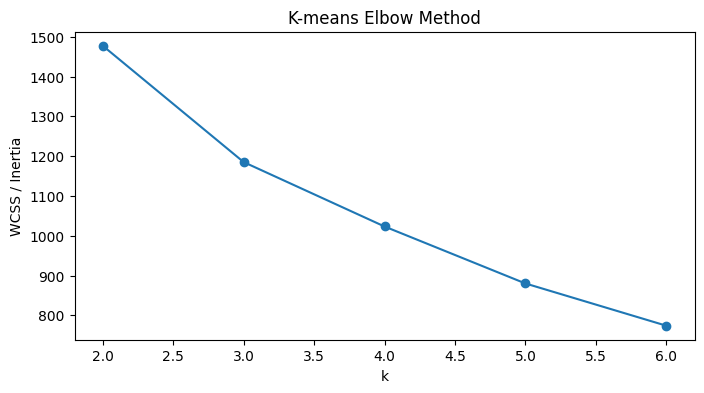

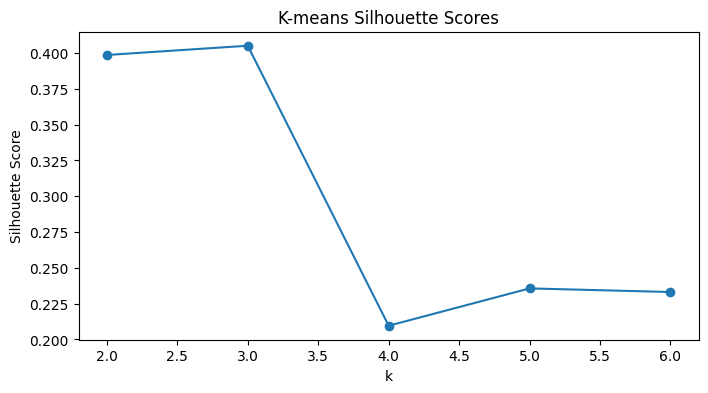


Best k based on silhouette: 3

Cluster counts:
Cluster
0    373
1    106
2      9
Name: count, dtype: int64

KMeans Cluster Profile (Option A)
         W_annual_return  W_annual_logvol  W_mean_logvolchg_1  Weight  \
Cluster                                                                 
0                 0.0649           0.2677             -0.0000  0.0011   
1                 0.2432           0.4019             -0.0012  0.0015   
2                 0.2853           0.2652             -0.0006  0.0157   

         n_stocks  
Cluster            
0             373  
1             106  
2               9  


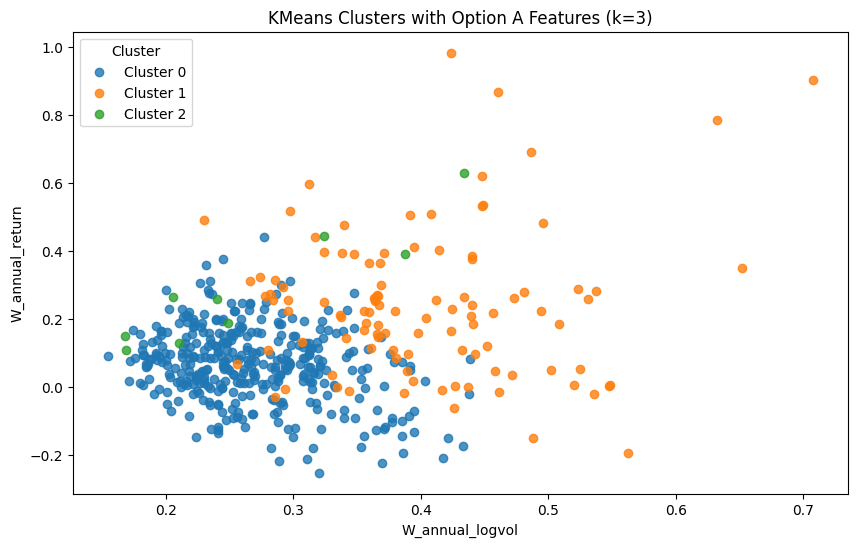


Sample stocks by cluster:
    Symbol                  Sector  Cluster  W_annual_return  W_annual_logvol  \
37     APH  Information Technology        0         0.440784         0.276970   
75     CAH             Health Care        0         0.375783         0.244431   
299    MCK             Health Care        0         0.358837         0.231829   
61      BK              Financials        0         0.312774         0.234398   
113    CRH               Materials        0         0.311887         0.297236   
484   WELL             Real Estate        0         0.305402         0.226848   
208    GLW  Information Technology        0         0.299439         0.290446   
107    COR             Health Care        0         0.285227         0.200380   
487    WMB                  Energy        0         0.283922         0.233139   
400    RTX             Industrials        0         0.276934         0.233827   
192    FIX             Industrials        1         0.982960         0.423803   
3

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# =========================================================
# 1. Helper functions
# =========================================================

def wavg(series, weights):
    valid = series.notna() & weights.notna()
    values = series[valid]
    w = weights[valid]
    return np.average(values, weights=w) if len(values) else np.nan


def build_datasets(csv_path, year_weights, guard_threshold=0.25):
    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

    g = df.groupby("Symbol", group_keys=False)

    # --- Daily features ---
    df["log_close"] = np.log(df["Close"])
    df["logret_1"] = g["log_close"].diff(1)
    df["logret_5"] = g["log_close"].diff(5)
    df["logret_21"] = g["log_close"].diff(21)

    df["logvol_5"] = (
        g["logret_1"].rolling(5).std().reset_index(level=0, drop=True)
    )
    df["logvol_21"] = (
        g["logret_1"].rolling(21).std().reset_index(level=0, drop=True)
    )

    df["log_volume"] = np.log(df["Volume"].clip(lower=1))
    df["logvolchg_1"] = g["log_volume"].diff(1)
    df["vol_ma_21"] = (
        g["Volume"].rolling(21).mean().reset_index(level=0, drop=True)
    )

    # Optional target
    df["logret_fwd_1"] = g["logret_1"].shift(-1)
    df["y"] = (df["logret_fwd_1"] > 0).astype(int)

    feature_cols = [
        "logret_1",
        "logret_5",
        "logret_21",
        "logvol_5",
        "logvol_21",
        "logvolchg_1",
        "vol_ma_21",
        "Weight",
        "Sector",
    ]

    df_model = df.dropna(subset=feature_cols).reset_index(drop=True)

    # --- Add year weights ---
    df_tmp = df_model.copy()
    df_tmp["Year"] = df_tmp["Date"].dt.year
    df_tmp["YearWeight"] = df_tmp["Year"].map(year_weights)
    df_tmp = df_tmp.dropna(subset=["YearWeight"]).copy()

    # Guardrail against extreme daily returns
    df_tmp = df_tmp[df_tmp["logret_1"].abs() <= guard_threshold].copy()

    # --- Yearly stock summary ---
    yearly = (
        df_tmp.groupby(["Symbol", "Sector", "Year"], as_index=False)
        .agg(
            mean_logret_1=("logret_1", "mean"),
            sd_logret_1=("logret_1", "std"),
            mean_logret_5=("logret_5", "mean"),
            mean_logret_21=("logret_21", "mean"),
            mean_logvol_21=("logvol_21", "mean"),
            mean_logvolchg_1=("logvolchg_1", "mean"),
            mean_vol_ma_21=("vol_ma_21", "mean"),
            Weight=("Weight", "first"),
            YearWeight=("YearWeight", "first"),
        )
    )

    # --- Weighted stock-level features ---
    weighted_stock = (
        yearly.groupby(["Symbol", "Sector"], as_index=False)
        .apply(
            lambda x: pd.Series(
                {
                    "W_mean_logret_1": wavg(x["mean_logret_1"], x["YearWeight"]),
                    "W_sd_logret_1": wavg(x["sd_logret_1"], x["YearWeight"]),
                    "W_mean_logret_5": wavg(x["mean_logret_5"], x["YearWeight"]),
                    "W_mean_logret_21": wavg(x["mean_logret_21"], x["YearWeight"]),
                    "W_mean_logvol_21": wavg(x["mean_logvol_21"], x["YearWeight"]),
                    "W_mean_logvolchg_1": wavg(x["mean_logvolchg_1"], x["YearWeight"]),
                    "W_mean_vol_ma_21": wavg(x["mean_vol_ma_21"], x["YearWeight"]),
                    "Weight": x["Weight"].iloc[0],
                }
            )
        )
        .reset_index(drop=True)
    )

    weighted_stock["W_annual_logret"] = weighted_stock["W_mean_logret_1"] * 252
    weighted_stock["W_annual_return"] = np.exp(weighted_stock["W_annual_logret"]) - 1
    weighted_stock["W_annual_logvol"] = weighted_stock["W_sd_logret_1"] * np.sqrt(252)

    return df, df_model, weighted_stock


def detect_outliers_mahalanobis(weighted_stock, feature_cols, alpha=0.001):
    df_feat = weighted_stock[["Symbol", "Sector"] + feature_cols].dropna().copy()

    X = df_feat[feature_cols].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    mean_vec = X_scaled.mean(axis=0)
    cov_mat = np.cov(X_scaled, rowvar=False)
    cov_inv = np.linalg.pinv(cov_mat)

    diff = X_scaled - mean_vec
    md_sq = np.sum(diff @ cov_inv * diff, axis=1)

    df_chi = X_scaled.shape[1]
    p_values = 1 - chi2.cdf(md_sq, df=df_chi)

    df_feat["Mahalanobis_D2"] = md_sq
    df_feat["p_value"] = p_values
    df_feat["Outlier"] = df_feat["p_value"] < alpha

    return df_feat


def get_clean_clustering_data(weighted_stock, feature_cols, alpha=0.001):
    outlier_df = detect_outliers_mahalanobis(weighted_stock, feature_cols, alpha=alpha)

    clean_df = outlier_df.loc[~outlier_df["Outlier"]].copy()

    clean_scaler = StandardScaler()
    clean_X_scaled = clean_scaler.fit_transform(clean_df[feature_cols].values)

    return outlier_df, clean_df, clean_X_scaled


def choose_k_kmeans(X_scaled, k_min=2, k_max=6, random_state=42):
    ks = list(range(k_min, k_max + 1))
    inertias = []
    silhouettes = []

    for k in ks:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    plt.figure(figsize=(8, 4))
    plt.plot(ks, inertias, marker="o")
    plt.xlabel("k")
    plt.ylabel("WCSS / Inertia")
    plt.title("K-means Elbow Method")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(ks, silhouettes, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title("K-means Silhouette Scores")
    plt.show()

    best_k = ks[int(np.argmax(silhouettes))]
    return {
        "k_values": ks,
        "inertia": inertias,
        "silhouette": silhouettes,
        "best_k": best_k
    }


def run_kmeans(clean_df, X_scaled, k=2, random_state=42):
    model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = model.fit_predict(X_scaled)

    result = clean_df.copy()
    result["Cluster"] = labels
    return result, model


def profile_clusters(result_df, feature_cols):
    summary = (
        result_df.groupby("Cluster")[feature_cols]
        .mean()
        .round(4)
    )
    summary["n_stocks"] = result_df["Cluster"].value_counts().sort_index()
    return summary


def plot_kmeans_clusters(result_df, title="KMeans Clusters"):
    plt.figure(figsize=(10, 6))

    for cluster in sorted(result_df["Cluster"].unique()):
        subset = result_df[result_df["Cluster"] == cluster]
        plt.scatter(
            subset["W_annual_logvol"],
            subset["W_annual_return"],
            label=f"Cluster {cluster}",
            alpha=0.8
        )

    plt.xlabel("W_annual_logvol")
    plt.ylabel("W_annual_return")
    plt.title(title)
    plt.legend(title="Cluster")
    plt.show()


# =========================================================
# 2. Parameters
# =========================================================

csv_path = "data/sp500_5yr_with_sectors_weights.csv"

# You can change these weights if needed
year_weights = {
    2020: 1,
    2021: 2,
    2022: 3,
    2023: 4,
    2024: 5,
    2025: 6,
}

# OPTION A feature set
CLUSTER_FEATURES_OPTION_A = [
    "W_annual_return",
    "W_annual_logvol",
    "W_mean_logvolchg_1",
    "Weight",
]

alpha = 0.001


# =========================================================
# 3. Build datasets
# =========================================================

df, df_model, weighted_stock = build_datasets(
    csv_path,
    year_weights=year_weights,
    guard_threshold=0.25
)

print("Original daily dataset shape:", df.shape)
print("Model-ready daily dataset shape:", df_model.shape)
print("Weighted stock dataset shape:", weighted_stock.shape)


# =========================================================
# 4. Detect outliers using Option A features
# =========================================================

outlier_df, clean_df, clean_X_scaled = get_clean_clustering_data(
    weighted_stock,
    CLUSTER_FEATURES_OPTION_A,
    alpha=alpha
)

print("\nNumber of outliers detected:", outlier_df["Outlier"].sum())
print("Number of clean stocks:", len(clean_df))

print("\nTop flagged outliers:")
print(
    outlier_df.loc[outlier_df["Outlier"], ["Symbol", "Sector", "Mahalanobis_D2", "p_value"]]
    .sort_values("Mahalanobis_D2", ascending=False)
    .head(15)
)


# =========================================================
# 5. Choose k for KMeans
# =========================================================

kmeans_k_results = choose_k_kmeans(clean_X_scaled, k_min=2, k_max=6)
print("\nBest k based on silhouette:", kmeans_k_results["best_k"])


# =========================================================
# 6. Fit final KMeans
# =========================================================

best_k = kmeans_k_results["best_k"]

kmeans_result, kmeans_model = run_kmeans(
    clean_df,
    clean_X_scaled,
    k=best_k,
    random_state=42
)

print("\nCluster counts:")
print(kmeans_result["Cluster"].value_counts().sort_index())


# =========================================================
# 7. Cluster summary
# =========================================================

summary_cols = [
    "W_annual_return",
    "W_annual_logvol",
    "W_mean_logvolchg_1",
    "Weight",
]

cluster_summary = profile_clusters(kmeans_result, summary_cols)

print("\nKMeans Cluster Profile (Option A)")
print(cluster_summary)


# =========================================================
# 8. Plot clusters
# =========================================================

plot_kmeans_clusters(
    kmeans_result,
    title=f"KMeans Clusters with Option A Features (k={best_k})"
)


# =========================================================
# 9. Optional: inspect a few stocks in each cluster
# =========================================================

print("\nSample stocks by cluster:")
print(
    kmeans_result[["Symbol", "Sector", "Cluster", "W_annual_return", "W_annual_logvol", "Weight"]]
    .sort_values(["Cluster", "W_annual_return"], ascending=[True, False])
    .groupby("Cluster")
    .head(10)
)

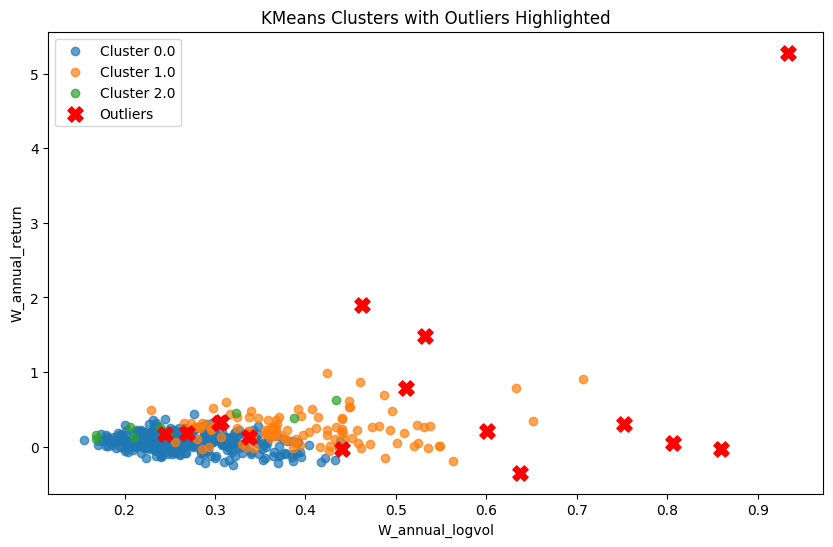

In [11]:
def plot_clusters_with_outliers(outlier_df, kmeans_result):
    plt.figure(figsize=(10, 6))

    # Merge cluster info back
    plot_df = outlier_df.merge(
        kmeans_result[["Symbol", "Cluster"]],
        on="Symbol",
        how="left"
    )

    # --- Plot clusters ---
    for cluster in sorted(plot_df["Cluster"].dropna().unique()):
        subset = plot_df[(plot_df["Cluster"] == cluster) & (~plot_df["Outlier"])]
        plt.scatter(
            subset["W_annual_logvol"],
            subset["W_annual_return"],
            label=f"Cluster {cluster}",
            alpha=0.7
        )

    # --- Plot outliers (very important visually) ---
    outliers = plot_df[plot_df["Outlier"] == True]

    plt.scatter(
        outliers["W_annual_logvol"],
        outliers["W_annual_return"],
        c="red",
        marker="X",
        s=120,
        label="Outliers"
    )

    # --- Labels ---
    plt.xlabel("W_annual_logvol")
    plt.ylabel("W_annual_return")
    plt.title("KMeans Clusters with Outliers Highlighted")

    plt.legend()
    plt.show()
    
plot_clusters_with_outliers(outlier_df, kmeans_result)

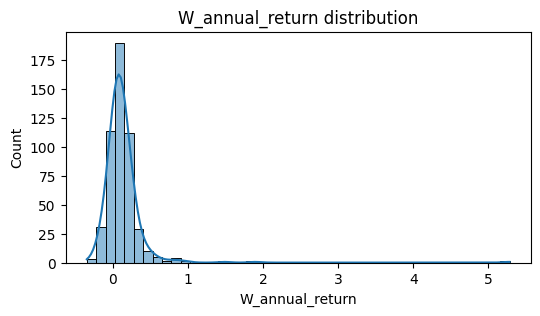

W_annual_return → Shapiro p-value: 0.00000
----------------------------------------


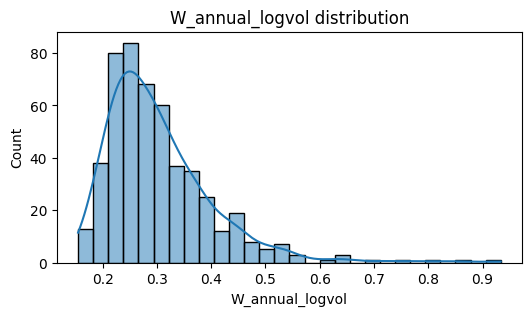

W_annual_logvol → Shapiro p-value: 0.00000
----------------------------------------


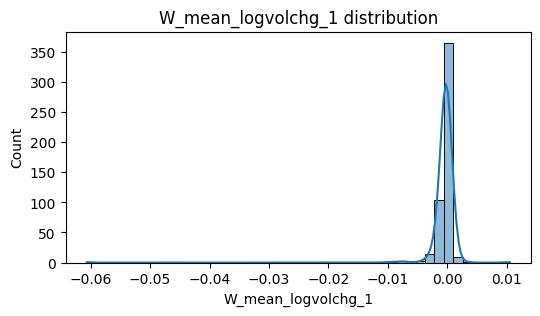

W_mean_logvolchg_1 → Shapiro p-value: 0.00000
----------------------------------------


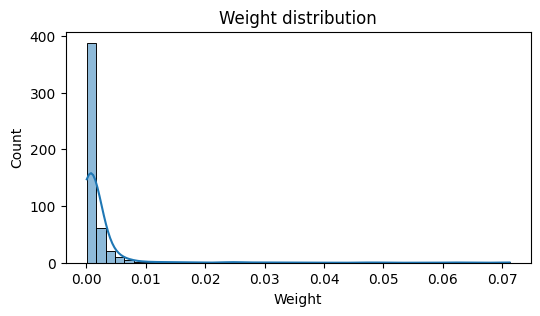

Weight → Shapiro p-value: 0.00000
----------------------------------------


In [13]:
import seaborn as sns
from scipy.stats import shapiro

def check_normality_features(df, feature_cols):
    for col in feature_cols:
        plt.figure(figsize=(6,3))

        sns.histplot(df[col], kde=True)
        plt.title(f"{col} distribution")
        plt.show()

        stat, p = shapiro(df[col].dropna())
        print(f"{col} → Shapiro p-value: {p:.5f}")
        print("-"*40)
        
check_normality_features(weighted_stock, CLUSTER_FEATURES_OPTION_A)

## Time-based clustering pipeline (3y train / 1y validation / 1y test)
This section builds clustering features from only the training window, then selects the best number of clusters for K-means and hierarchical clustering using silhouette score.

Rules implemented:
- Last 1 year = test
- Previous 1 year = validation
- Previous 3 years = training
- Keep stocks that appear in train, validation, and test
- Require at least 6 distinct months of data in training

C:\Users\cynth\AppData\Local\Temp\ipykernel_27860\1618301622.py:121: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Split boundaries:
{'train_start': Timestamp('2021-03-20 00:00:00'), 'val_start': Timestamp('2024-03-20 00:00:00'), 'test_start': Timestamp('2025-03-20 00:00:00'), 'test_end': Timestamp('2026-03-20 00:00:00')}

Training year weights used: {np.int32(2021): 1, np.int32(2022): 2, np.int32(2023): 3, np.int32(2024): 4}
Eligible symbols: 499
Clustering rows after NA/drop filters: 499


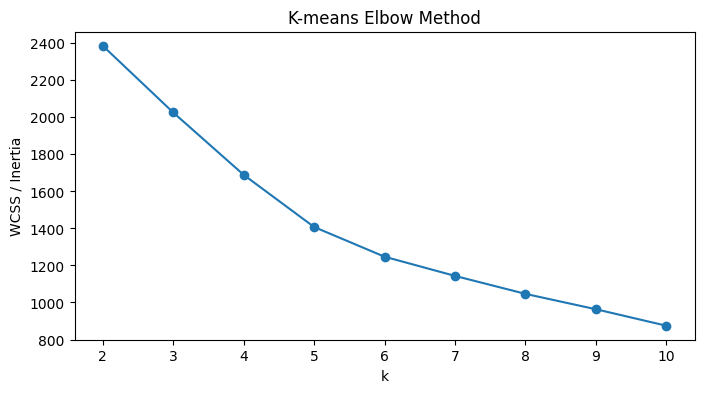

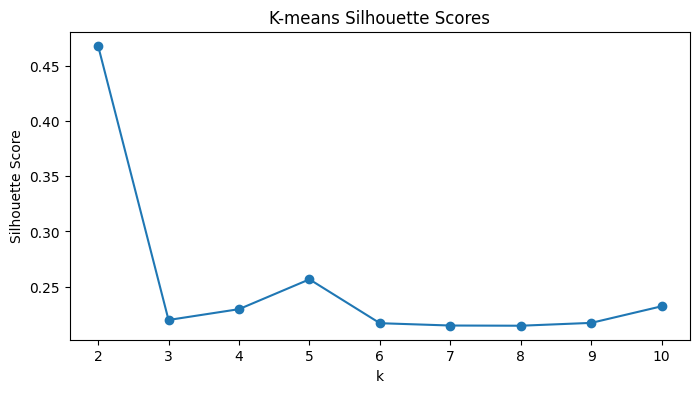

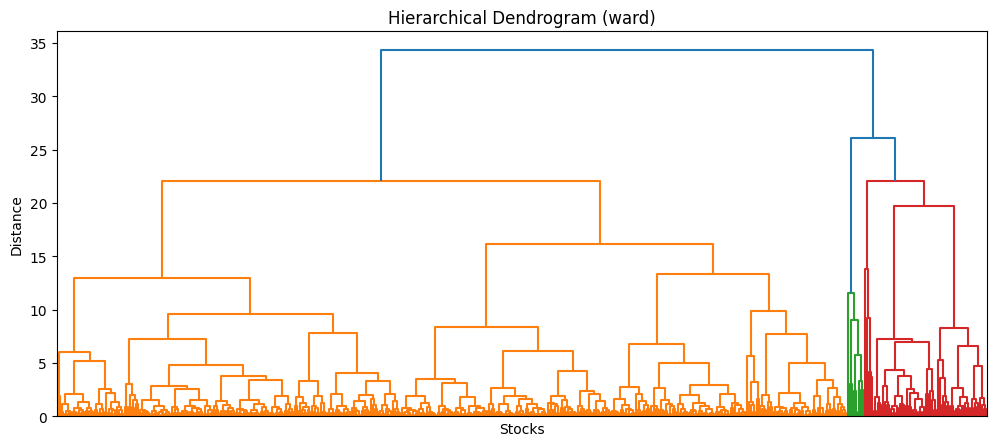

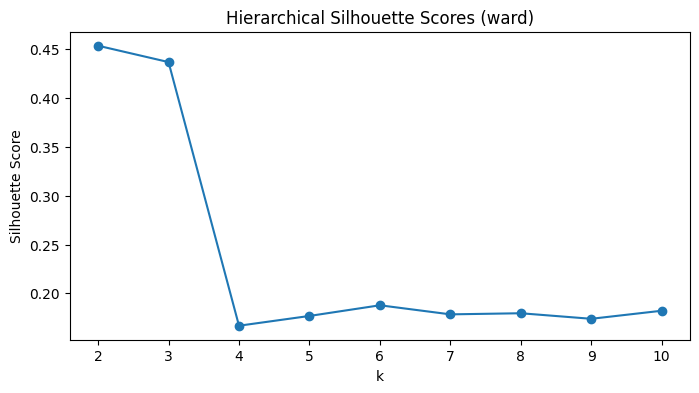


Best k for K-means: 2
Best k for Hierarchical: 2

K-means cluster profile
         W_mean_logret_5  W_mean_logret_21  W_mean_logvol_21  W_sd_logret_1  \
Cluster                                                                       
0                 0.0067            0.0310            0.0277         0.0283   
1                 0.0023            0.0113            0.0158         0.0162   

         W_mean_logvolchg_1  Weight  n_stocks  
Cluster                                        
0                    0.0000  0.0064        70  
1                    0.0025  0.0013       429  

Hierarchical cluster profile
         W_mean_logret_5  W_mean_logret_21  W_mean_logvol_21  W_sd_logret_1  \
Cluster                                                                       
0                 0.0064            0.0298            0.0273         0.0278   
1                 0.0023            0.0112            0.0158         0.0162   

         W_mean_logvolchg_1  Weight  n_stocks  
Cluster              

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score


def wavg(series, weights):
    valid = series.notna() & weights.notna()
    values = series[valid]
    w = weights[valid]
    return np.average(values, weights=w) if len(values) else np.nan


def add_daily_features(df):
    df = df.copy()
    df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)
    g = df.groupby("Symbol", group_keys=False)

    df["log_close"] = np.log(df["Close"])
    df["logret_1"] = g["log_close"].diff(1)
    df["logret_5"] = g["log_close"].diff(5)
    df["logret_21"] = g["log_close"].diff(21)
    df["logvol_5"] = g["logret_1"].rolling(5).std().reset_index(level=0, drop=True)
    df["logvol_21"] = g["logret_1"].rolling(21).std().reset_index(level=0, drop=True)
    df["log_volume"] = np.log(df["Volume"].clip(lower=1))
    df["logvolchg_1"] = g["log_volume"].diff(1)
    df["vol_ma_21"] = g["Volume"].rolling(21).mean().reset_index(level=0, drop=True)

    return df


def assign_time_windows(df, train_years=3, val_years=1, test_years=1):
    max_date = df["Date"].max()
    test_end = max_date
    test_start = test_end - pd.DateOffset(years=test_years)
    val_start = test_start - pd.DateOffset(years=val_years)
    train_start = val_start - pd.DateOffset(years=train_years)

    df = df.copy()
    df["Split"] = np.select(
        [
            (df["Date"] >= train_start) & (df["Date"] < val_start),
            (df["Date"] >= val_start) & (df["Date"] < test_start),
            (df["Date"] >= test_start) & (df["Date"] <= test_end),
        ],
        ["train", "val", "test"],
        default="other",
    )

    bounds = {
        "train_start": train_start,
        "val_start": val_start,
        "test_start": test_start,
        "test_end": test_end,
    }
    return df, bounds


def select_eligible_symbols(df, min_train_months=6):
    in_windows = df[df["Split"].isin(["train", "val", "test"])].copy()

    symbols_train = set(in_windows.loc[in_windows["Split"] == "train", "Symbol"].unique())
    symbols_val = set(in_windows.loc[in_windows["Split"] == "val", "Symbol"].unique())
    symbols_test = set(in_windows.loc[in_windows["Split"] == "test", "Symbol"].unique())

    present_all = symbols_train & symbols_val & symbols_test

    train_df = in_windows[in_windows["Split"] == "train"].copy()
    train_df["YearMonth"] = train_df["Date"].dt.to_period("M")
    months_by_symbol = train_df.groupby("Symbol")["YearMonth"].nunique()
    enough_train_months = set(months_by_symbol[months_by_symbol >= min_train_months].index)

    eligible = sorted(present_all & enough_train_months)
    return eligible


def build_train_clustering_table(df, eligible_symbols, guard_threshold=0.25):
    feature_cols_daily = [
        "logret_1",
        "logret_5",
        "logret_21",
        "logvol_5",
        "logvol_21",
        "logvolchg_1",
        "vol_ma_21",
        "Weight",
    ]

    train = df[(df["Split"] == "train") & (df["Symbol"].isin(eligible_symbols))].copy()
    train = train.dropna(subset=feature_cols_daily)
    train = train[train["logret_1"].abs() <= guard_threshold].copy()

    train["Year"] = train["Date"].dt.year

    # Recency weighting inside training period (oldest=1, newest=n)
    years = sorted(train["Year"].dropna().unique())
    year_weights = {yr: i + 1 for i, yr in enumerate(years)}
    train["YearWeight"] = train["Year"].map(year_weights)

    yearly = (
        train.groupby(["Symbol", "Sector", "Year"], as_index=False)
        .agg(
            mean_logret_1=("logret_1", "mean"),
            sd_logret_1=("logret_1", "std"),
            mean_logret_5=("logret_5", "mean"),
            mean_logret_21=("logret_21", "mean"),
            mean_logvol_21=("logvol_21", "mean"),
            mean_logvolchg_1=("logvolchg_1", "mean"),
            mean_vol_ma_21=("vol_ma_21", "mean"),
            Weight=("Weight", "first"),
            YearWeight=("YearWeight", "first"),
        )
    )

    weighted_stock = (
        yearly.groupby(["Symbol", "Sector"], as_index=False)
        .apply(
            lambda x: pd.Series(
                {
                    "W_mean_logret_1": wavg(x["mean_logret_1"], x["YearWeight"]),
                    "W_sd_logret_1": wavg(x["sd_logret_1"], x["YearWeight"]),
                    "W_mean_logret_5": wavg(x["mean_logret_5"], x["YearWeight"]),
                    "W_mean_logret_21": wavg(x["mean_logret_21"], x["YearWeight"]),
                    "W_mean_logvol_21": wavg(x["mean_logvol_21"], x["YearWeight"]),
                    "W_mean_logvolchg_1": wavg(x["mean_logvolchg_1"], x["YearWeight"]),
                    "W_mean_vol_ma_21": wavg(x["mean_vol_ma_21"], x["YearWeight"]),
                    "Weight": x["Weight"].iloc[0],
                }
            )
        )
        .reset_index(drop=True)
    )

    weighted_stock["W_annual_logret"] = weighted_stock["W_mean_logret_1"] * 252
    weighted_stock["W_annual_return"] = np.exp(weighted_stock["W_annual_logret"]) - 1
    weighted_stock["W_annual_logvol"] = weighted_stock["W_sd_logret_1"] * np.sqrt(252)

    return weighted_stock, year_weights


def choose_k_kmeans(X_scaled, k_min=2, k_max=10, random_state=42):
    max_valid_k = min(k_max, X_scaled.shape[0] - 1)
    ks = list(range(k_min, max_valid_k + 1))
    inertias = []
    silhouettes = []

    for k in ks:
        model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = model.fit_predict(X_scaled)
        inertias.append(model.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    plt.figure(figsize=(8, 4))
    plt.plot(ks, inertias, marker="o")
    plt.xlabel("k")
    plt.ylabel("WCSS / Inertia")
    plt.title("K-means Elbow Method")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(ks, silhouettes, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title("K-means Silhouette Scores")
    plt.show()

    best_k = ks[int(np.argmax(silhouettes))]
    return {"k_values": ks, "inertia": inertias, "silhouette": silhouettes, "best_k": best_k}


def choose_k_hierarchical(X_scaled, k_min=2, k_max=10, method="ward"):
    Z = linkage(X_scaled, method=method)

    plt.figure(figsize=(12, 5))
    dendrogram(Z, no_labels=True)
    plt.title(f"Hierarchical Dendrogram ({method})")
    plt.xlabel("Stocks")
    plt.ylabel("Distance")
    plt.show()

    max_valid_k = min(k_max, X_scaled.shape[0] - 1)
    ks = list(range(k_min, max_valid_k + 1))
    silhouettes = []

    for k in ks:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)
        silhouettes.append(silhouette_score(X_scaled, labels))

    plt.figure(figsize=(8, 4))
    plt.plot(ks, silhouettes, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title(f"Hierarchical Silhouette Scores ({method})")
    plt.show()

    best_k = ks[int(np.argmax(silhouettes))]
    return {"k_values": ks, "silhouette": silhouettes, "best_k": best_k}


def run_kmeans(clean_df, X_scaled, k=3, random_state=42):
    model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = model.fit_predict(X_scaled)
    result = clean_df.copy()
    result["Cluster"] = labels
    return result, model


def run_hierarchical(clean_df, X_scaled, k=3, linkage_method="ward"):
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    labels = model.fit_predict(X_scaled)
    result = clean_df.copy()
    result["Cluster"] = labels
    return result, model


def profile_clusters(result_df, feature_cols):
    summary = result_df.groupby("Cluster")[feature_cols].mean().round(4)
    summary["n_stocks"] = result_df["Cluster"].value_counts().sort_index()
    return summary


csv_path = "data/sp500_5yr_with_sectors_weights.csv"
CLUSTER_FEATURES = [
    "W_mean_logret_5",
    "W_mean_logret_21",
    "W_mean_logvol_21",
    "W_sd_logret_1",
    "W_mean_logvolchg_1",
    "Weight",
]

raw = pd.read_csv(csv_path)
raw["Date"] = pd.to_datetime(raw["Date"])
df_feat = add_daily_features(raw)
df_split, bounds = assign_time_windows(df_feat, train_years=3, val_years=1, test_years=1)

eligible_symbols = select_eligible_symbols(df_split, min_train_months=6)
weighted_stock, train_year_weights = build_train_clustering_table(
    df_split,
    eligible_symbols=eligible_symbols,
    guard_threshold=0.25,
    )

cluster_df = weighted_stock[["Symbol", "Sector"] + CLUSTER_FEATURES].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[CLUSTER_FEATURES].values)

print("Split boundaries:")
print(bounds)
print("\nTraining year weights used:", train_year_weights)
print("Eligible symbols:", len(eligible_symbols))
print("Clustering rows after NA/drop filters:", len(cluster_df))

kmeans_k_results = choose_k_kmeans(X_scaled, k_min=2, k_max=10, random_state=42)
hier_k_results = choose_k_hierarchical(X_scaled, k_min=2, k_max=10, method="ward")

print("\nBest k for K-means:", kmeans_k_results["best_k"])
print("Best k for Hierarchical:", hier_k_results["best_k"])

kmeans_result, _ = run_kmeans(
    cluster_df, X_scaled, k=kmeans_k_results["best_k"], random_state=42
)
hier_result, _ = run_hierarchical(
    cluster_df, X_scaled, k=hier_k_results["best_k"], linkage_method="ward"
)

print("\nK-means cluster profile")
print(profile_clusters(kmeans_result, CLUSTER_FEATURES))

print("\nHierarchical cluster profile")
print(profile_clusters(hier_result, CLUSTER_FEATURES))

## Feature tuning for clustering
This section compares multiple feature sets and ranks them by silhouette score.

What it does:
- Evaluates each candidate feature subset
- Selects best k for K-means and hierarchical clustering
- Reports best silhouette for each method
- Produces a ranking table so you can choose stronger feature sets

In [2]:
from itertools import combinations


def best_k_and_score_kmeans(X_scaled, k_min=2, k_max=10, random_state=42):
    max_valid_k = min(k_max, X_scaled.shape[0] - 1)
    if max_valid_k < k_min:
        return np.nan, np.nan

    best_k = None
    best_score = -np.inf

    for k in range(k_min, max_valid_k + 1):
        model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_k = k

    return best_k, best_score


def best_k_and_score_hierarchical(X_scaled, k_min=2, k_max=10, method="ward"):
    max_valid_k = min(k_max, X_scaled.shape[0] - 1)
    if max_valid_k < k_min:
        return np.nan, np.nan

    best_k = None
    best_score = -np.inf

    for k in range(k_min, max_valid_k + 1):
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_k = k

    return best_k, best_score


def evaluate_feature_sets(weighted_stock, candidate_feature_sets, k_min=2, k_max=10):
    rows = []

    for i, features in enumerate(candidate_feature_sets, start=1):
        df_eval = weighted_stock[["Symbol", "Sector"] + list(features)].dropna().copy()
        n_obs = len(df_eval)

        if n_obs < 5:
            rows.append(
                {
                    "set_id": f"set_{i}",
                    "features": ", ".join(features),
                    "n_obs": n_obs,
                    "kmeans_best_k": np.nan,
                    "kmeans_best_silhouette": np.nan,
                    "hier_best_k": np.nan,
                    "hier_best_silhouette": np.nan,
                    "avg_best_silhouette": np.nan,
                    "note": "too_few_observations",
                }
            )
            continue

        scaler = StandardScaler()
        X_scaled_local = scaler.fit_transform(df_eval[list(features)].values)

        k_km, s_km = best_k_and_score_kmeans(X_scaled_local, k_min=k_min, k_max=k_max)
        k_hc, s_hc = best_k_and_score_hierarchical(X_scaled_local, k_min=k_min, k_max=k_max, method="ward")

        rows.append(
            {
                "set_id": f"set_{i}",
                "features": ", ".join(features),
                "n_obs": n_obs,
                "kmeans_best_k": k_km,
                "kmeans_best_silhouette": s_km,
                "hier_best_k": k_hc,
                "hier_best_silhouette": s_hc,
                "avg_best_silhouette": np.nanmean([s_km, s_hc]),
                "note": "ok",
            }
        )

    results = pd.DataFrame(rows).sort_values("avg_best_silhouette", ascending=False).reset_index(drop=True)
    return results


# Base pool from your engineered train features
feature_pool = [
    "W_mean_logret_5",
    "W_mean_logret_21",
    "W_mean_logvol_21",
    "W_sd_logret_1",
    "W_mean_logvolchg_1",
    "Weight",
    "W_annual_return",
    "W_annual_logvol",
]

# Candidate sets: your current set + selected combinations
candidate_sets = [
    tuple(CLUSTER_FEATURES),
    ("W_annual_return", "W_annual_logvol", "W_mean_logvolchg_1", "Weight"),
    ("W_mean_logret_5", "W_sd_logret_1", "W_mean_logvol_21", "Weight"),
]

for combo in combinations(feature_pool, 4):
    candidate_sets.append(combo)

# Remove duplicates while preserving order
seen = set()
dedup_candidate_sets = []
for fs in candidate_sets:
    key = tuple(fs)
    if key not in seen:
        seen.add(key)
        dedup_candidate_sets.append(fs)

tuning_results = evaluate_feature_sets(
    weighted_stock=weighted_stock,
    candidate_feature_sets=dedup_candidate_sets,
    k_min=2,
    k_max=10,
    )

print("Top 10 feature sets by average best silhouette:")
display(tuning_results.head(10))

best_row = tuning_results.iloc[0]
print("\nBest feature set overall:")
print(best_row[["features", "kmeans_best_k", "kmeans_best_silhouette", "hier_best_k", "hier_best_silhouette"]])

# Optional: set best features for downstream reruns
BEST_CLUSTER_FEATURES = best_row["features"].split(", ")
print("\nBEST_CLUSTER_FEATURES:", BEST_CLUSTER_FEATURES)

Top 10 feature sets by average best silhouette:


,set_id,features,n_obs,kmeans_best_k,kmeans_best_silhouette,hier_best_k,hier_best_silhouette,avg_best_silhouette,note
0,set_43,"W_mean_logret_21, W_mean_logvol_21, W_mean_log...",499,2,0.720704,2,0.720704,0.720704,ok
1,set_65,"W_mean_logvol_21, W_mean_logvolchg_1, Weight, ...",499,2,0.717108,2,0.717108,0.717108,ok
2,set_73,"W_mean_logvolchg_1, Weight, W_annual_return, W...",499,2,0.708675,2,0.720383,0.714529,ok
3,set_69,"W_sd_logret_1, W_mean_logvolchg_1, Weight, W_a...",499,2,0.708675,2,0.720383,0.714529,ok
4,set_2,"W_annual_return, W_annual_logvol, W_mean_logvo...",499,2,0.708675,2,0.720383,0.714529,ok
5,set_23,"W_mean_logret_5, W_mean_logvol_21, W_mean_logv...",499,2,0.706412,2,0.706412,0.706412,ok
6,set_56,"W_mean_logret_21, W_mean_logvolchg_1, Weight, ...",499,2,0.705331,2,0.705331,0.705331,ok
7,set_49,"W_mean_logret_21, W_sd_logret_1, W_mean_logvol...",499,2,0.705331,2,0.705331,0.705331,ok
8,set_29,"W_mean_logret_5, W_sd_logret_1, W_mean_logvolc...",499,2,0.704686,2,0.704686,0.704686,ok
9,set_36,"W_mean_logret_5, W_mean_logvolchg_1, Weight, W...",499,2,0.704686,2,0.704686,0.704686,ok



Best feature set overall:
features                  W_mean_logret_21, W_mean_logvol_21, W_mean_log...
kmeans_best_k                                                             2
kmeans_best_silhouette                                             0.720704
hier_best_k                                                               2
hier_best_silhouette                                               0.720704
Name: 0, dtype: object

BEST_CLUSTER_FEATURES: ['W_mean_logret_21', 'W_mean_logvol_21', 'W_mean_logvolchg_1', 'Weight']


## Visual comparison for k=2 and k=3
This plot compares K-means and hierarchical clustering using your selected BEST_CLUSTER_FEATURES.

All panels use the same 2D PCA projection of standardized features for fair visual comparison.

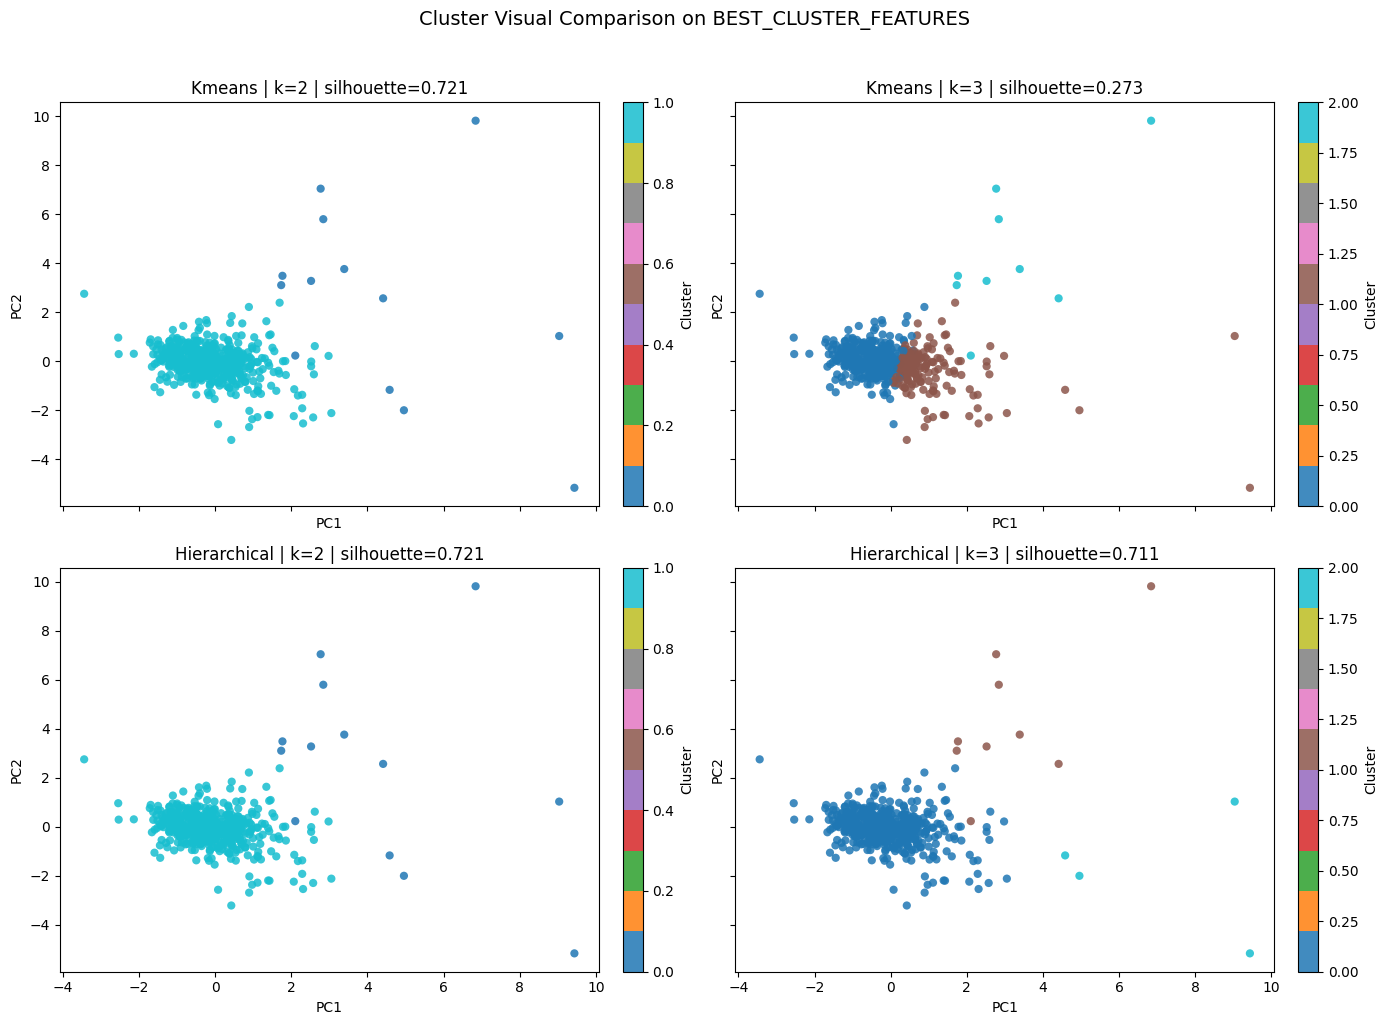

Explained variance ratio (PC1, PC2): [0.3586 0.2591]
Features used: ['W_mean_logret_21', 'W_mean_logvol_21', 'W_mean_logvolchg_1', 'Weight']


In [3]:
from sklearn.decomposition import PCA

# Build dataset using selected best features
viz_df = weighted_stock[["Symbol", "Sector"] + BEST_CLUSTER_FEATURES].dropna().copy()

scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(viz_df[BEST_CLUSTER_FEATURES].values)

# Common 2D projection for all panels
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_viz_scaled)

def fit_labels(X, method, k):
    if method == "kmeans":
        model = KMeans(n_clusters=k, n_init=20, random_state=42)
    elif method == "hierarchical":
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    else:
        raise ValueError("Unknown method")

    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    return labels, sil

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
configs = [
    ("kmeans", 2, axes[0, 0]),
    ("kmeans", 3, axes[0, 1]),
    ("hierarchical", 2, axes[1, 0]),
    ("hierarchical", 3, axes[1, 1]),
]

for method, k, ax in configs:
    labels, sil = fit_labels(X_viz_scaled, method=method, k=k)
    scatter = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=labels,
        cmap="tab10",
        s=35,
        alpha=0.85,
        edgecolor="none",
    )
    ax.set_title(f"{method.title()} | k={k} | silhouette={sil:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label="Cluster")

plt.suptitle("Cluster Visual Comparison on BEST_CLUSTER_FEATURES", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_.round(4))
print("Features used:", BEST_CLUSTER_FEATURES)

In [4]:
# PCA loadings for interpretability
loadings = pd.DataFrame(
    pca.components_.T,
    index=BEST_CLUSTER_FEATURES,
    columns=["PC1", "PC2"],
)

loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()

print("PCA loadings (raw coefficients):")
display(loadings[["PC1", "PC2"]].sort_values("PC1", key=lambda s: s.abs(), ascending=False))

print("\nTop contributors to PC1 (by absolute loading):")
display(loadings[["PC1", "abs_PC1"]].sort_values("abs_PC1", ascending=False))

print("\nTop contributors to PC2 (by absolute loading):")
display(loadings[["PC2", "abs_PC2"]].sort_values("abs_PC2", ascending=False))

PCA loadings (raw coefficients):


,PC1,PC2
W_mean_logvol_21,0.598224,-0.361459
W_mean_logvolchg_1,-0.542704,0.417500
W_mean_logret_21,0.490025,0.423036
Weight,0.327837,0.718388



Top contributors to PC1 (by absolute loading):


,PC1,abs_PC1
W_mean_logvol_21,0.598224,0.598224
W_mean_logvolchg_1,-0.542704,0.542704
W_mean_logret_21,0.490025,0.490025
Weight,0.327837,0.327837



Top contributors to PC2 (by absolute loading):


,PC2,abs_PC2
Weight,0.718388,0.718388
W_mean_logret_21,0.423036,0.423036
W_mean_logvolchg_1,0.417500,0.417500
W_mean_logvol_21,-0.361459,0.361459
